In [1]:
import intake
import matplotlib.pyplot as plt
import cmocean as cm
import numpy as np
from dask.distributed import Client
from scipy.interpolate import interp1d
from gsw import sigma0, sigma1, sigma2, CT_from_pt, SA_from_SP, p_from_z

import xarray as xr
import cf_xarray as cfxr
import warnings

In [2]:
client = Client(threads_per_worker = 1, memory_limit = '2900gb')

2025-10-07 17:26:52,419 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 2900gb due to system memory limit of 1.43 TiB
2025-10-07 17:26:52,422 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 2900gb due to system memory limit of 1.43 TiB
2025-10-07 17:26:52,424 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 2900gb due to system memory limit of 1.43 TiB
2025-10-07 17:26:52,427 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 2900gb due to system memory limit of 1.43 TiB
2025-10-07 17:26:52,429 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 2900gb due to system memory limit of 1.43 TiB
2025-10-07 17:26:52,431 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 2900gb due to system memory limit of 1.43 TiB
2025-10-07 17:26:52,434 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 2900gb due to system memory limit of 1.43 TiB
2025-10-07 17:26:52,

In [60]:
#in this definition, no frequency can be used only for static data
catalog = intake.cat.access_nri
def importer(experiment,catalog,variable, frequency = 'fx',start_time=0,end_time=0,chunks=''):
    warnings.filterwarnings('ignore')
    if variable=='T_ady' or variable=='thetao':
        var = catalog[experiment].search(variable=variable, frequency = frequency)
        keysnames = var.keys() ; search_term = "z_l"
        matches = [s for s in keysnames if search_term in s]
        var = catalog[experiment].search(variable=variable, frequency = frequency,file_id = matches).to_dask(xarray_open_kwargs={'decode_timedelta':True},chunks=chunks)
    elif variable=='siconc':
        var = catalog[experiment].search(variable=variable, frequency = frequency)
        keysnames = var.keys() ; search_term = "xB"
        matches = [s for s in keysnames if search_term in s]
        var = catalog[experiment].search(variable=variable, frequency = frequency,file_id = matches).to_dask(xarray_open_kwargs={'decode_timedelta':True},chunks=chunks)
    else:
        var = catalog[experiment].search(variable=variable, frequency = frequency).to_dask(xarray_open_kwargs={'decode_timedelta':True},chunks=chunks)
    
    if start_time!=0:
        time_slice='slice(start_time,end_time)'
        return eval("var." + variable + ".sel(time=" + time_slice + ")")
    elif start_time ==0:
        return eval("var." + variable)

In [4]:
#panan sessions
start_time = '1999-01-01'
end_time = '2001-12-31'
time_slice=slice(start_time, end_time)


In [5]:
lat_slice  = slice(-83,-59)

figdir = '/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/figs/'

In [22]:
#lets import the the density to see how it changes along isobaths
#Importing Potential temperature in panan01
MHT01_z = importer("panant-01-zstar-ACCESSyr2",catalog,'T_ady',frequency = '1mon',start_time = start_time, end_time =end_time,chunks={'xh':500,'yq':846,'time':36,'z_l':1}).sel(time = slice( start_time, end_time)).mean('time').sum('xh')
MHT005_z = importer("panant-005-zstar-ACCESSyr2",catalog,'T_ady',frequency = '1mon',start_time = start_time, end_time =end_time,chunks={'xh':7200,'yq':'250gb','time':36,'z_l':'250gb'}).sel(time = slice( start_time, end_time)).mean('time').sum('xh')
MHT0025_z = importer("panant-0025-zstar-ACCESSyr2",catalog,'T_ady',frequency = '1mon',start_time = start_time, end_time =end_time,chunks={'xh':7000,'yq':'500gb','time':24,'z_l':75}).sel(time = slice( start_time, end_time)).mean('time').sum('xh')


In [26]:
%%time
MHT0025_z.load()
MHT0025_z.to_netcdf('/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan0025_rerun/MHT_z_panan0025.nc')
print('Average meridional heat transport (y,z) loaded for panan0025')

Average meridional heat transport (y,z) loaded for panan0025
CPU times: user 9min 47s, sys: 1min 9s, total: 10min 57s
Wall time: 11min 3s


In [29]:
%%time
MHT005_z.load()
MHT005_z.to_netcdf('/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan005_rerun/MHT_z_panan005.nc')
print('Average meridional heat transport (y,z) loaded for panan005')

Average meridional heat transport (y,z) loaded for panan005
CPU times: user 3min 22s, sys: 29 s, total: 3min 51s
Wall time: 3min 53s


In [30]:
%%time
MHT01_z.load()
MHT01_z.to_netcdf('/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan01_rerun/MHT_z_panan01.nc')
print('Average meridional heat transport (y,z) loaded for panan01')

Average meridional heat transport (y,z) loaded for panan01
CPU times: user 18 s, sys: 2.52 s, total: 20.5 s
Wall time: 20.9 s


In [31]:
#integrating values in depth too
MHT01=MHT01_z.sum('z_l')
MHT005=MHT005_z.sum('z_l')
MHT0025=MHT0025_z.sum('z_l')

Text(0.5, 1.0, 'Total ocean meridional heat transport (Negative=Southwards)')

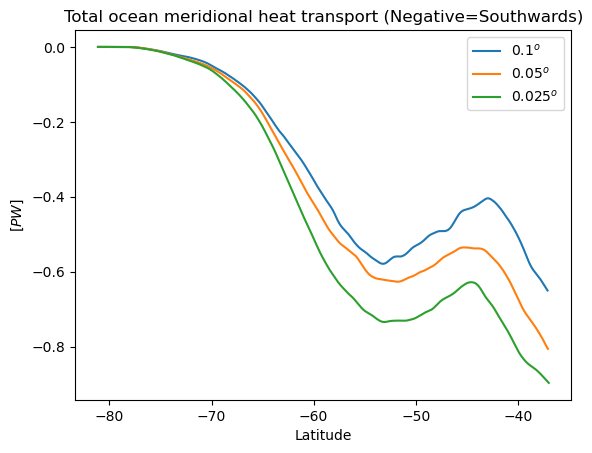

In [35]:
(1e-15 * MHT01).plot(label=r'$0.1^o$')
(1e-15 * MHT005).plot(label=r'$0.05^o$')
(1e-15 * MHT0025).plot(label=r'$0.025^o$')
plt.legend()
plt.ylabel('[$PW$]')
plt.xlabel('Latitude')
plt.title('Total ocean meridional heat transport (Negative=Southwards)')
plt.savefig('/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/figs/total_ocean_meridional_heat_transport.png',dpi=300,bbox_inches='tight')

Interestingly, the total meridional heat transport in the oceans increase from 1/10th to 1/20th to 1/40th to a quite big rate

Maybe the increase in heat transport with resolution increases the ammount of heat stored near the sea ice dge, and the heat fluxes in these regions. 

Let's save the values oh MHT, because they are quite expensive to run

In [38]:
MHT01.name = 'MHT'
MHT01 = MHT01.assign_attrs(units="PW")
MHT005.name = 'MHT'
MHT005 = MHT005.assign_attrs(units="PW")
MHT0025.name = 'MHT'
MHT0025 = MHT0025.assign_attrs(units="PW")

In [39]:
MHT01.to_netcdf('/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan01_rerun/MHT_panan01.nc')
MHT005.to_netcdf('/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan005_rerun/MHT_panan005.nc')
MHT0025.to_netcdf('/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan0025_rerun/MHT_panan0025.nc')

In [37]:
#reinporting vertically integraeted heat transport
MHT01 = xr.open_dataset('/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan01_rerun/MHT_panan01.nc').MHT
MHT005 = xr.open_dataset('/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan005_rerun/MHT_panan005.nc').MHT
MHT0025 = xr.open_dataset('/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan0025_rerun/MHT_panan0025.nc').MHT

#reinporting layerwise heat transport
MHT01_z = xr.open_dataset('/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan01_rerun/MHT_z_panan01.nc').T_ady
MHT005_z = xr.open_dataset('/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan005_rerun/MHT_z_panan005.nc').T_ady
MHT0025_z = xr.open_dataset('/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan0025_rerun/MHT_z_panan0025.nc').T_ady

How does the mean winter SST changes with latitude?

In [48]:
%%time
#lets import the SSTs
SST0025 = importer("panant-0025-zstar-ACCESSyr2",catalog,'thetao',frequency = '1mon',start_time = start_time, end_time =end_time,chunks={'xh':7000,'yh':'500gb','time':24,'z_l':75})\
    .sel(time = slice( start_time, end_time)).isel(z_l=0).groupby('time.month').mean().compute()
SST005 = importer("panant-005-zstar-ACCESSyr2",catalog,'thetao',frequency = '1mon',start_time = start_time, end_time =end_time,chunks={'xh':7200,'yh':'250gb','time':36,'z_l':'250gb'})\
    .sel(time = slice( start_time, end_time)).isel(z_l=0).groupby('time.month').mean().compute()
SST01 = importer("panant-01-zstar-ACCESSyr2",catalog,'thetao',frequency = '1mon',start_time = start_time, end_time =end_time,chunks={'xh':500,'yh':846,'time':36,'z_l':1})\
    .sel(time = slice( start_time, end_time)).isel(z_l=0).groupby('time.month').mean().compute()

CPU times: user 9min 6s, sys: 1min 6s, total: 10min 13s
Wall time: 10min 29s


In [49]:
# #lets import the SSTs
# #panan01
# SST01= cc.querying.getvar('mom6-panan','thetao',session_p01_orig,frequency='1 monthly',ncfile = '%ocean_month_z%',\
#                             start_time=start_time,end_time=end_time,chunks={'xh':500,'yh':846,'time':36,'z_l':1}).sel(time = slice( start_time, end_time)).isel(z_l=0).groupby('time.month').mean()
# #panan005
# SST005= cc.querying.getvar('panant-005-zstar-ACCESSyr2','thetao',session_p005,frequency='1 monthly',ncfile = '%ocean_month_z%',\
#                             start_time=start_time,end_time=end_time,chunks={'xh':7200,'yh':'250gb','time':36,'z_l':'250gb'}).sel(time = slice( start_time, end_time)).isel(z_l=0).groupby('time.month').mean()
# #panan0025
# SST0025= cc.querying.getvar('panant-0025-zstar-ACCESSyr2','thetao',session_p0025,frequency='1 monthly',ncfile = '%ocean_month_z%',\
#                             start_time=start_time,end_time=end_time,chunks={'xh':7000,'yh':'500gb','time':24,'z_l':75}).sel(time = slice( start_time, end_time)).isel(z_l=0).groupby('time.month').mean()


In [50]:
Month_inds = slice(8,10)
SST01_winter =SST01.sel(month = Month_inds).mean('month')
SST005_winter =SST005.sel(month = Month_inds).mean('month')
SST0025_winter =SST0025.sel(month = Month_inds).mean('month')

In [51]:
# zonal means
ZM_SST0025_winter = SST0025_winter.mean('xh').compute()
ZM_SST005_winter = SST005_winter.mean('xh').compute()
ZM_SST01_winter = SST01_winter.mean('xh').compute()

In [55]:
var = catalog["panant-01-zstar-ACCESSyr2"].search(variable='siconc', frequency = '1mon',file = 'seaIce.1mon.nv:2.xB:3601.xT:3600.xTe:3601.yB:846.yT:845.yTe:846')
var.keys()

['seaIce.1mon.nv:2.xB:3601.xT:3600.xTe:3601.yB:846.yT:845.yTe:846',
 'seaIce.1mon.nv:2.xT:3600.xTe:3601.yT:845.yTe:846']

In [62]:
%%time
#lets import the SSTs
SIC0025 = importer("panant-0025-zstar-ACCESSyr2",catalog,'siconc',frequency = '1mon',start_time = start_time, end_time =end_time,chunks={'xT':7000,'yT':'500gb','time':24})\
    .sel(time = slice( start_time, end_time)).groupby('time.month').mean().compute()
SIC005 = importer("panant-005-zstar-ACCESSyr2",catalog,'siconc',frequency = '1mon',start_time = start_time, end_time =end_time,chunks={'xT':7200,'yT':'250gb','time':36})\
    .sel(time = slice( start_time, end_time)).groupby('time.month').mean().compute()
SIC01 = importer("panant-01-zstar-ACCESSyr2",catalog,'siconc',frequency = '1mon',start_time = start_time, end_time =end_time,chunks={'xT':500,'yT':846,'time':36})\
    .sel(time = slice( start_time, end_time)).groupby('time.month').mean().compute()

CPU times: user 1min 12s, sys: 13.9 s, total: 1min 26s
Wall time: 1min 31s


In [64]:
Month_inds = slice(8,10)
SIC01_winter =SIC01.sel(month = Month_inds).mean('month')
SIC005_winter =SIC005.sel(month = Month_inds).mean('month')
SIC0025_winter =SIC0025.sel(month = Month_inds).mean('month')

In [65]:
# zonal means
ZM_SIC0025_winter = SIC0025_winter.mean('xT').compute()
ZM_SIC005_winter = SIC005_winter.mean('xT').compute()
ZM_SIC01_winter = SIC01_winter.mean('xT').compute()

(-68.0, -55.0)

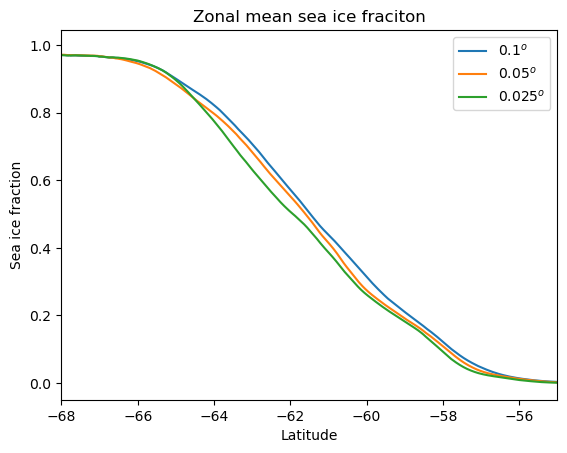

In [66]:
(ZM_SIC01_winter).plot(label=r'$0.1^o$')
(ZM_SIC005_winter).plot(label=r'$0.05^o$')
(ZM_SIC0025_winter).plot(label=r'$0.025^o$')
plt.legend()
plt.ylabel('Sea ice fraction')
plt.xlabel('Latitude')
plt.title('Zonal mean sea ice fraciton')
plt.xlim(-68,-55)
#plt.ylim(-2,2)

In [67]:
#finding the the latitude of the zonal mean 2C line
target_temp=2

#panan01           ########################################################################
diff01 = abs(ZM_SST01_winter - target_temp)
# Find the xh (longitude) where this difference is minimal
lat_closest01 = ZM_SST01_winter['yh'][diff01.argmin().item()]
temp_closest01 = ZM_SST01_winter.sel(yh=lat_closest01)

#panan005           ########################################################################
diff005 = abs(ZM_SST005_winter - target_temp)
# Find the xh (longitude) where this difference is minimal
lat_closest005 = ZM_SST005_winter['yh'][diff005.argmin().item()]
temp_closest005 = ZM_SST005_winter.sel(yh=lat_closest005)

#panan0025           ########################################################################
diff0025 = abs(ZM_SST0025_winter - target_temp)
# Find the xh (longitude) where this difference is minimal
lat_closest0025 = ZM_SST0025_winter['yh'][diff0025.argmin().item()]
temp_closest0025 = ZM_SST0025_winter.sel(yh=lat_closest0025)

How does these patterns look together and when plotted against each other?

In [68]:
# Interpolating SST for latitudinal alignment
ZM_SST01_winter_yq = ZM_SST01_winter.interp(yh = MHT01.yq)
ZM_SST005_winter_yq = ZM_SST005_winter.interp(yh = MHT005.yq)
ZM_SST0025_winter_yq = ZM_SST0025_winter.interp(yh = MHT0025.yq)

# Interpolating SIC for latitudinal alignment
ZM_SIC01_winter_yq = ZM_SIC01_winter.interp(yT = MHT01.yq)
ZM_SIC005_winter_yq = ZM_SIC005_winter.interp(yT = MHT005.yq)
ZM_SIC0025_winter_yq = ZM_SIC0025_winter.interp(yT = MHT0025.yq)

(-0.01, 0.4)

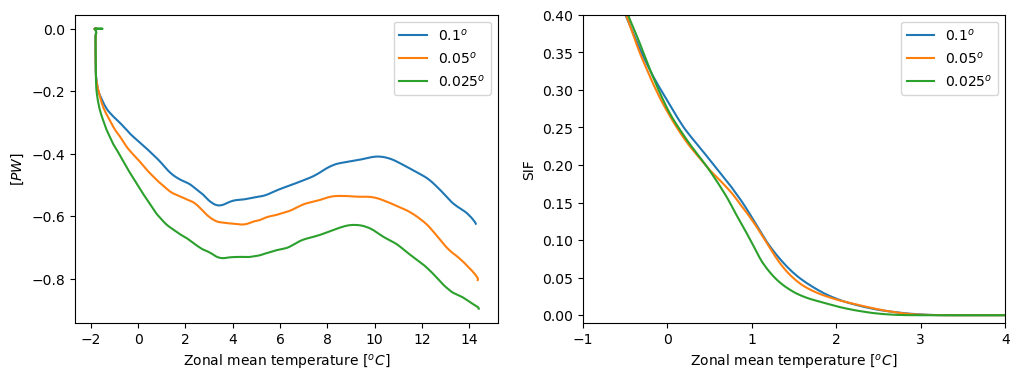

In [69]:
plt.figure(figsize = (12,4))

plt.subplot(1,2,1)
plt.plot(ZM_SST01_winter_yq,1e-15 * MHT01,label=r'$0.1^o$')
plt.plot(ZM_SST005_winter_yq,1e-15 * MHT005,label=r'$0.05^o$')
plt.plot(ZM_SST0025_winter_yq,1e-15 * MHT0025,label=r'$0.025^o$')
plt.xlabel(r'Zonal mean temperature [$^oC$]')
plt.ylabel('[$PW$]')
plt.legend()

plt.subplot(1,2,2)
plt.plot(ZM_SST01_winter_yq,ZM_SIC01_winter_yq,label=r'$0.1^o$')
plt.plot(ZM_SST005_winter_yq,ZM_SIC005_winter_yq,label=r'$0.05^o$')
plt.plot(ZM_SST0025_winter_yq,ZM_SIC0025_winter_yq,label=r'$0.025^o$')
plt.xlabel(r'Zonal mean temperature [$^oC$]')
plt.ylabel('SIF')
plt.legend()
plt.xlim(-1,4)
plt.ylim(-.01,0.4)

In [70]:
from matplotlib.patches import Polygon

In [104]:
%%time
#importing mixed layer depth  - mlotst- "Ocean Mixed Layer Thickness Defined by Sigma T" ;
#lets import the SSTs
MLD0025 = importer("panant-0025-zstar-ACCESSyr2",catalog,'mlotst',frequency = '1mon',start_time = start_time, end_time =end_time,chunks={'xh':7000,'yh':'500gb','time':24})\
    .sel(time = slice( start_time, end_time)).groupby('time.month').mean().compute()
MLD005 = importer("panant-005-zstar-ACCESSyr2",catalog,'mlotst',frequency = '1mon',start_time = start_time, end_time =end_time,chunks={'xh':7200,'yh':'250gb','time':36})\
    .sel(time = slice( start_time, end_time)).groupby('time.month').mean().compute()
MLD01 = importer("panant-01-zstar-ACCESSyr2",catalog,'mlotst',frequency = '1mon',start_time = start_time, end_time =end_time,chunks={'xh':500,'yTh':846,'time':36})\
    .sel(time = slice( start_time, end_time)).groupby('time.month').mean().compute()

CPU times: user 1min 13s, sys: 12.5 s, total: 1min 26s
Wall time: 1min 35s


In [129]:
#selecting MLD in the latitude and times where we will show the PHT profile 
north_SIlat = -55
MLD0025_maxTime_ZM = MLD0025.cf.sel({'latitude':north_SIlat},method='nearest').mean('xh').max()
MLD005_maxTime_ZM = MLD005.cf.sel({'latitude':north_SIlat},method='nearest').mean('xh').max()
MLD01_maxTime_ZM = MLD01.cf.sel({'latitude':north_SIlat},method='nearest').mean('xh').max()

In [130]:
MLD0025_maxTime_ZM,MLD005_maxTime_ZM,MLD01_maxTime_ZM

(<xarray.DataArray 'mlotst' ()> Size: 8B
 array(166.12113953)
 Coordinates:
     yh       float64 8B -55.0,
 <xarray.DataArray 'mlotst' ()> Size: 8B
 array(239.90383911)
 Coordinates:
     yh       float64 8B -55.0,
 <xarray.DataArray 'mlotst' ()> Size: 8B
 array(234.79632568)
 Coordinates:
     yh       float64 8B -55.01)

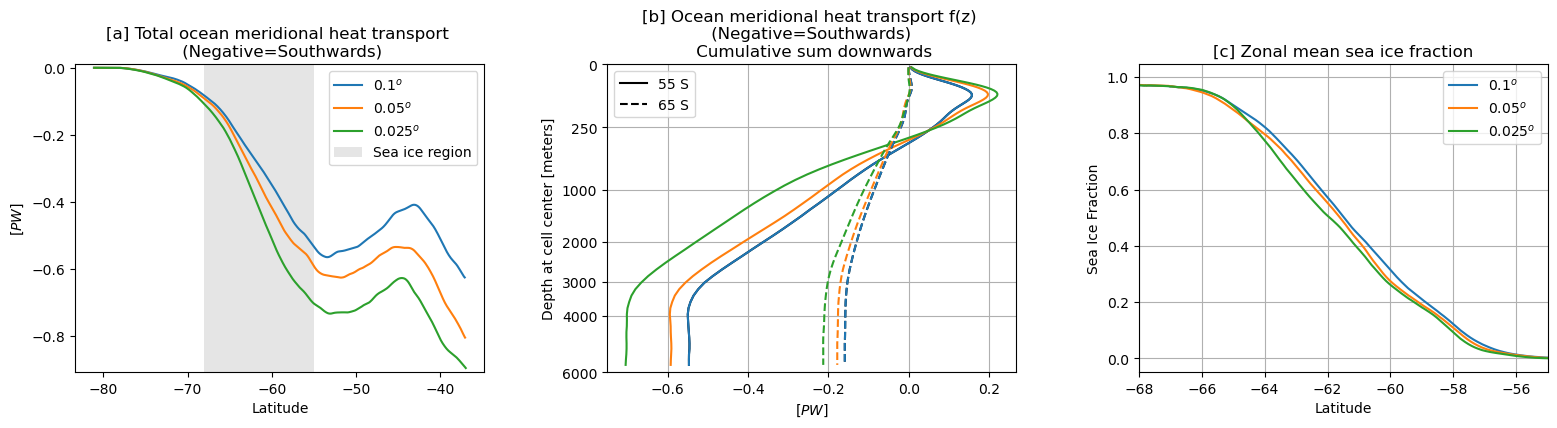

In [218]:
plt.figure(figsize = (19,4))
plt.subplots_adjust(wspace=0.3, hspace=0.3)


vertices = [(-68, -1), (-68, 0.1), (-55, 0.1), (-55, -1),(-68, -1)]
polygon = Polygon(vertices, closed=True, facecolor='grey', edgecolor=None,alpha=0.2,label='Sea ice region')

# Add the polygon to the axes
ax = plt.subplot(1,3,1)
(1e-15 * MHT01).plot(label=r'$0.1^o$')
(1e-15 * MHT005).plot(label=r'$0.05^o$')
(1e-15 * MHT0025).plot(label=r'$0.025^o$')
ax.add_patch(polygon)
plt.legend()
plt.ylim(-0.91,0.01)
plt.ylabel('[$PW$]')

plt.xlabel('Latitude')
plt.title('[a] Total ocean meridional heat transport \n (Negative=Southwards)')


# Function x**(1/2)
def forward(x):
    return x**(1/2)
def inverse(x):
    return x**2

ax2 = plt.subplot(1,3,2)
(1e-15 * MHT01_z).cumsum('z_l').cf.sel({'latitude':north_SIlat},method='nearest').plot(y='z_l',color='k',label=[str(np.abs(north_SIlat)) + ' S'])
(1e-15 * MHT01_z).cumsum('z_l').cf.sel({'latitude':north_SIlat},method='nearest').plot(y='z_l',color='tab:blue')
(1e-15 * MHT005_z).cumsum('z_l').cf.sel({'latitude':north_SIlat},method='nearest').plot(y='z_l',color='tab:orange')
(1e-15 * MHT0025_z).cumsum('z_l').cf.sel({'latitude':north_SIlat},method='nearest').plot(y='z_l',color='tab:green')

middle_SIlat = -65
(1e-15 * MHT01_z).cumsum('z_l').cf.sel({'latitude':middle_SIlat},method='nearest').plot(linestyle='--',y='z_l',color='k',label=[str(np.abs(middle_SIlat)) + ' S'])
(1e-15 * MHT01_z).cumsum('z_l').cf.sel({'latitude':middle_SIlat},method='nearest').plot(linestyle='--',y='z_l',color='tab:blue')
(1e-15 * MHT005_z).cumsum('z_l').cf.sel({'latitude':middle_SIlat},method='nearest').plot(linestyle='--',y='z_l',color='tab:orange')
(1e-15 * MHT0025_z).cumsum('z_l').cf.sel({'latitude':middle_SIlat},method='nearest').plot(linestyle='--',y='z_l',color='tab:green')

ax2.set_yscale('function', functions=(forward, inverse))
ax2.set_yticks(ticks=[0,250,1000,2000,3000,4000,6000])
plt.grid()
plt.legend()
plt.ylim(6000,0)
plt.xlabel('[$PW$]')
plt.title('[b] Ocean meridional heat transport f(z) \n (Negative=Southwards) \n ' + r'Cumulative sum downwards' )


plt.subplot(1,3,3)
#lat_closest01 ZM_SST01_winter
ZM_SIC01_winter.plot(label=r'$0.1^o$',color='tab:blue')
ZM_SIC005_winter.plot(label=r'$0.05^o$',color='tab:orange')
ZM_SIC0025_winter.plot(label=r'$0.025^o$',color='tab:green')
plt.legend()
plt.xlim(-68,-55)
#plt.ylim(-2,3)
plt.ylabel('Sea Ice Fraction')
plt.xlabel('Latitude')
plt.title('[c] Zonal mean sea ice fraction')
plt.grid()
plt.savefig('/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/figs/total_ocean_meridional_heat_transport.png',dpi=300,bbox_inches='tight')

The increase in heat transport in the northern sea ice edge occurs mostly below the MLD at this latitude, so we expect that the at this latitude, in the MLD there shouldnt be additional heat available to melt sea ice. this means that some process needs to bring this heat to the surface to melt sea ice

Let's cauculate the MHT divergence. For that we need to interpolat the values to the same grid.

In [139]:
MHT0025_into01 = MHT0025.groupby_bins('yq',bins = SST01.yh).sum().rename({'yq_bins':'yq'})
MHT005_into01 = MHT005.groupby_bins('yq',bins = SST01.yh).sum().rename({'yq_bins':'yq'})
# MHT0025_into01['yq']=MHT01
# MHT005_into01['yq']=MHT01

In [149]:
%%time
#first, importing areas()
areacello01 = importer("panant-01-zstar-ACCESSyr2",catalog,'areacello')
areacello005 = importer("panant-005-zstar-ACCESSyr2",catalog,'areacello')
areacello0025 = importer("panant-0025-zstar-ACCESSyr2",catalog,'areacello')

#lets also import heat transport to the atmosphere and compare it with the heat convergences
HF0025 = (importer("panant-0025-zstar-ACCESSyr2",catalog,'hfds',frequency = '1mon',start_time = start_time, end_time =end_time,chunks={'xh':7000,'yh':'500gb','time':24})\
    .sel(time = slice( start_time, end_time)).mean('time') * areacello0025).sum('xh').compute()
HF005 = (importer("panant-005-zstar-ACCESSyr2",catalog,'hfds',frequency = '1mon',start_time = start_time, end_time =end_time,chunks={'xh':7200,'yh':'250gb','time':36})\
    .sel(time = slice( start_time, end_time)).mean('time') * areacello005).sum('xh').compute()
HF01 = (importer("panant-01-zstar-ACCESSyr2",catalog,'hfds',frequency = '1mon',start_time = start_time, end_time =end_time,chunks={'xh':500,'yTh':846,'time':36})\
    .sel(time = slice( start_time, end_time)).mean('time') * areacello01).sum('xh').compute()

CPU times: user 40 s, sys: 4.31 s, total: 44.3 s
Wall time: 44.1 s


In [161]:
HF0025_into01 = HF0025.groupby_bins('yh',bins = MHT01.yq).sum().rename({'yh_bins':'yh'})
HF005_into01 = HF005.groupby_bins('yh',bins = MHT01.yq).sum().rename({'yh_bins':'yh'})

Text(0.5, 1.0, '[b] Ocean-atmosphere heat fluxes')

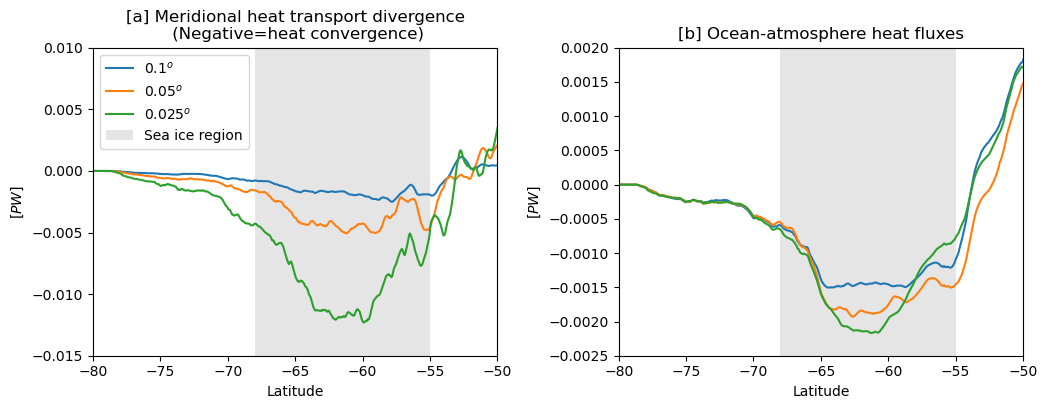

In [173]:
plt.figure(figsize = (12,4))
plt.subplots_adjust(wspace=0.3, hspace=0.3)






ax = plt.subplot(1,2,1)
vertices = [(-68, -1), (-68, 0.1), (-55, 0.1), (-55, -1),(-68, -1)]
polygon = Polygon(vertices, closed=True, facecolor='grey', edgecolor=None,alpha=0.2,label='Sea ice region')
#---
(1e-15 * MHT01.diff('yq')).plot(label=r'$0.1^o$')
(1e-15 * MHT005_into01.diff('yq')).plot(label=r'$0.05^o$')
(1e-15 * MHT0025_into01.diff('yq')).plot(label=r'$0.025^o$')
# plt.plot([-68,-68],[-1,0.1],color='grey',linewidth=0.5)
# plt.plot([-55,-55],[-1,0.1],color='grey',linewidth=0.5)
ax.add_patch(polygon)
plt.legend()
plt.ylim(-0.015,0.01)
plt.xlim(-80,-50)
plt.ylabel('[$PW$]')
plt.xlabel('Latitude')
plt.title('[a] Meridional heat transport divergence\n (Negative=heat convergence)')







ax1 = plt.subplot(1,2,2)
vertices = [(-68, -1), (-68, 0.1), (-55, 0.1), (-55, -1),(-68, -1)]
polygon = Polygon(vertices, closed=True, facecolor='grey', edgecolor=None,alpha=0.2,label='Sea ice region')
#---
(1e-15 * HF01).plot(label=r'$0.1^o$')
(1e-15 * HF005_into01).plot(label=r'$0.05^o$')
(1e-15 * HF0025_into01).plot(label=r'$0.025^o$')
ax1.add_patch(polygon)
plt.ylim(-0.0025,0.002)
plt.xlim(-80,-50)
plt.ylabel('[$PW$]')
plt.xlabel('Latitude')
plt.title('[b] Ocean-atmosphere heat fluxes')

It seems that we do have changes in the heat fluxes to the atmosphere, but they are much smaller than the heat convergence. which likely explains the extra heat soted in the higher resolutions. lets see that in a bar plot for convenience

Text(0.5, 1.0, '[b] Changes with resolution in the sea ice zone')

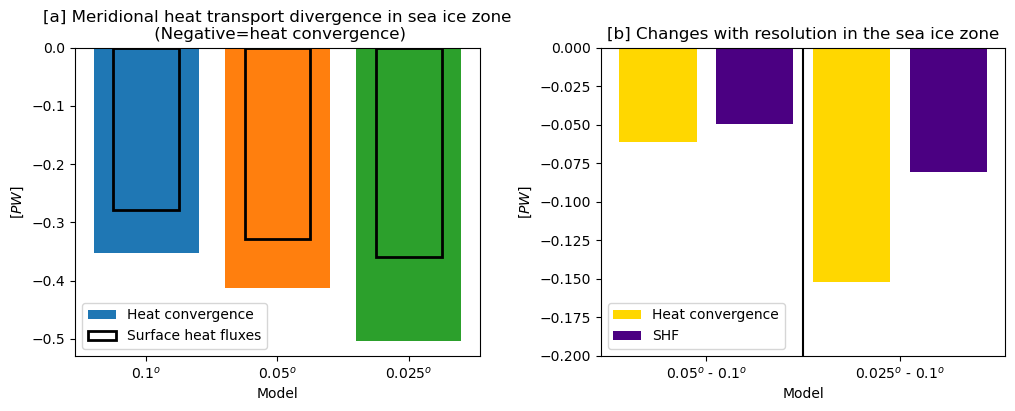

In [235]:
plt.figure(figsize = (12,4))
plt.subplots_adjust(wspace=0.3, hspace=0.3)



ice_slice=slice(-68,-58)


ax = plt.subplot(1,2,1)
plt.bar([0,1,2],[ (1e-15 * MHT01.diff('yq')).cf.sel({'latitude':ice_slice}).cf.sum({'latitude'}),\
        (1e-15 * MHT005.diff('yq')).cf.sel({'latitude':ice_slice}).cf.sum({'latitude'}),\
        (1e-15 * MHT0025.diff('yq')).cf.sel({'latitude':ice_slice}).cf.sum({'latitude'})], color=['tab:blue','tab:orange','tab:green'],label='Heat convergence')

plt.bar([0,1,2],[ (1e-15 * HF01).cf.sel({'latitude':ice_slice}).cf.sum({'latitude'}),\
        (1e-15 * HF005).cf.sel({'latitude':ice_slice}).cf.sum({'latitude'}),\
        (1e-15 * HF0025).cf.sel({'latitude':ice_slice}).cf.sum({'latitude'})], edgecolor='k',color='none',width= 0.5,linewidth=2,label='Surface heat fluxes')

plt.xticks(ticks=[0,1,2],labels=[r'$0.1^o$',r'$0.05^o$',r'$0.025^o$'])
plt.ylabel('[$PW$]')
plt.xlabel('Model')
plt.title('[a] Meridional heat transport divergence in sea ice zone\n (Negative=heat convergence)')
plt.legend()


ax1 = plt.subplot(1,2,2)
delta_MHT005 = (1e-15 * MHT005.diff('yq')).cf.sel({'latitude':ice_slice}).cf.sum({'latitude'}) - (1e-15 * MHT01.diff('yq')).cf.sel({'latitude':ice_slice}).cf.sum({'latitude'}) #relative ot 0.1
delta_MHT0025 = (1e-15 * MHT0025.diff('yq')).cf.sel({'latitude':ice_slice}).cf.sum({'latitude'}) - (1e-15 * MHT01.diff('yq')).cf.sel({'latitude':ice_slice}).cf.sum({'latitude'}) #relative ot 0.1
delta_HF005 = (1e-15 * HF005).cf.sel({'latitude':ice_slice}).cf.sum({'latitude'}) - (1e-15 * HF01).cf.sel({'latitude':ice_slice}).cf.sum({'latitude'}) #relative ot 0.1
delta_HF0025 = (1e-15 * HF0025).cf.sel({'latitude':ice_slice}).cf.sum({'latitude'}) - (1e-15 * HF01).cf.sel({'latitude':ice_slice}).cf.sum({'latitude'}) #relative ot 0.1

plt.bar([0,2],[ delta_MHT005,delta_MHT0025], color=['gold'],label='Heat convergence')
plt.bar([1,3],[ delta_HF005,delta_HF0025], color=['indigo'],label='SHF')
plt.plot([1.5,1.5],[-0.2,0],color='k')
plt.xticks(ticks=[0.5,2.5],labels=[r'$0.05^o$ - $0.1^o$',r'$0.025^o$ - $0.1^o$'])
plt.legend()
plt.ylim(-0.2,0)
plt.ylabel('[$PW$]')
plt.xlabel('Model')
plt.title('[b] Changes with resolution in the sea ice zone')

## SIT lookup

**Notice that here we are using start/end dates instead of time, as this is a single year of daily data. single year used because we are importing dailyd ata, so we need efficiency**

In [268]:
%%time
start_date='2000-01-01'
end_date = '2001-01-01'
#importing sea ice thickness
SIT_0025 = importer("panant-0025-zstar-ACCESSyr2",catalog,"sithick",frequency = '1day',start_time = start_date, end_time =end_date).chunk(chunks={'xT':'15gb','yT':'15gb','time':'15gb'}).compute()
SIT_005 = importer("panant-005-zstar-ACCESSyr2",catalog,"sithick",frequency = '1day',start_time = start_date, end_time =end_date).chunk(chunks={'xT':'15gb','yT':'15gb','time':'15gb'}).compute()
SIT_01 = importer("panant-01-zstar-ACCESSyr2",catalog,"sithick",frequency = '1day',start_time = start_date, end_time =end_date).chunk(chunks={'xT':'15gb','yT':'15gb','time':'15gb'}).compute()



CPU times: user 6min 46s, sys: 3min 38s, total: 10min 24s
Wall time: 12min 41s
